# Phase 1 Report: EDA

## Team Introduction
Our team consists of:
- Kahf Hussain - Data Scientist and Engineer (EDA, Modelling, Analyzing)
- Naren Garapati- Data Scientist
- Nosherwan Babar - Skill + Role
- Atharva Thoke - Skill + Role

## Abstract
This project explores the intersection of user financial data, credit card usage, and transaction behavior to understand patterns between spending behaviors among users based on their personal and financial factors. Using data from multiple sources, we aim to profile users, analyze spending patterns, and predict churn. These kinds of models and findings are valuable for banks, financial institutions, and common people to better their decision-making process for daily transactions.

## Introduction
In this project, we aim to bridge the gap between user demographics, credit card data, and transactional activities to understand:
- How financial profiles influence spending patterns.
- What transaction trends can tell us about user preferences.
- How inactivity or churn can be predicted to retain users.

The analysis focuses on three key areas:
1. **User Financial Profiling**: Understanding and clustering users based on demographics, income, and credit card usage patterns.
2. **Transaction Behavior Analysis**: Identifying top merchant categories, average transaction amounts, trends in transaction season, and trends in transaction methods (chip vs. non-chip; online vs in-person).
3. **Churn Prediction**: Using historical activity to predict user churn and understand factors that most influence returning customers.

## Audience and Use Cases
Our analysis is designed for stakeholders like banks, credit card companies, financial analysts, and common users. These insights can:
- Help banks assess credit risk more effectively.
- Enable marketing teams to target specific user segments.
- Support customer retention efforts by identifying churn risks.
- Help customers understand their spending capacity based on their financial status.


## Dataset Source

Our dataset is sourced from Kaggle, contributed by Caixabank Tech for 2024 AI Hackathon. The dataset can be accessed [here](https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets/data).

The dataset consists of 3 data files:
1. **User Data (`users_data.csv`)**: Demographic and account-related details for customers.
2. **Cards Information (`cards_data.csv`)** : Credit and Debit card details linked to customer accounts via `card_id`.
3. **Transaction Data (`transactions_data.csv`)** : Detailed transaction records including amounts, timestamps, customer and merchant details.

And 2 support files:
1. **Merchant Category Codes (`mcc_codes.json`)**: Standard classification codes for business types.
2. **Fraud Labels (`train_fraud_labels.json`)** : Binary classifications labels for transaction that show if the transactions were fraudulent or legitimate.

## Required Libraries and Set-Up for Overall Code.

In [3]:
!pip3 install geopandas

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import geopandas as gpd
from shapely.geometry import Point

In [5]:
# Define a default style and size for plots
plt.rcParams['figure.figsize'] = [12, 6]  # Set the default figure size
plt.rcParams['figure.dpi'] = 100  # Set dots per inch for higher clarity
plt.rcParams['axes.titlesize'] = 14  # Title font size
plt.rcParams['axes.labelsize'] = 12  # Axes label font size
plt.rcParams['xtick.labelsize'] = 10  # X-axis tick font size
plt.rcParams['ytick.labelsize'] = 10  # Y-axis tick font size
plt.rcParams['legend.fontsize'] = 10  # Legend font size
plt.rcParams['lines.linewidth'] = 2  # Line width for plots

## Dataset Overview

Let us now begin our EDA on each of the datasets by exploring their structure and content. This will help us understand their size, attributes, and any potential data quality issues.

In [6]:
def getInformationAboutFile(filepath):
  data_table = pd.read_csv(filepath)
  print(data_table.info())
  return data_table

## Understanding Users Data

In [7]:
users_data = getInformationAboutFile('./data/users_data.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   object 
 6   address            2000 non-null   object 
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   object 
 10  yearly_income      2000 non-null   object 
 11  total_debt         2000 non-null   object 
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 218.9+ KB
None


### Column Descriptions

The `users_data` dataset contains demographic and financial details about 2000 users. Below is a description of each column:

| Column Name           | Description                                                           |
|-----------------------|-----------------------------------------------------------------------|
| **id**                | A unique identifier for each user.                                    |
| **current_age**       | The current age of the user in years.                                 |
| **retirement_age**    | The age at which the user plans to retire.                            |
| **birth_year**        | The year of birth for the user.                                       |
| **birth_month**       | The month of birth for the user (1 for January, 12 for December).     |
| **gender**            | The gender of the user (e.g., Male, Female).                          |
| **address**           | The residential address of the user.                                  |
| **latitude**          | The latitude coordinate of the user's address.                        |
| **longitude**         | The longitude coordinate of the user's address.                       |
| **per_capita_income** | The average income per person in the user's household.                |
| **yearly_income**     | The annual income of the user.                                        |
| **total_debt**        | The total outstanding debt of the user.                               |
| **credit_score**      | The user's credit score, a numeric measure of their creditworthiness. |
| **num_credit_cards**  | The number of credit cards owned by the user.                         |                                    |

As we can see from the summary above, we don't have any empty or non-null values.

### Age Distribitution

Let us first understand the age group of the customers we are analysing and see if there are any patterns we should be aware of.

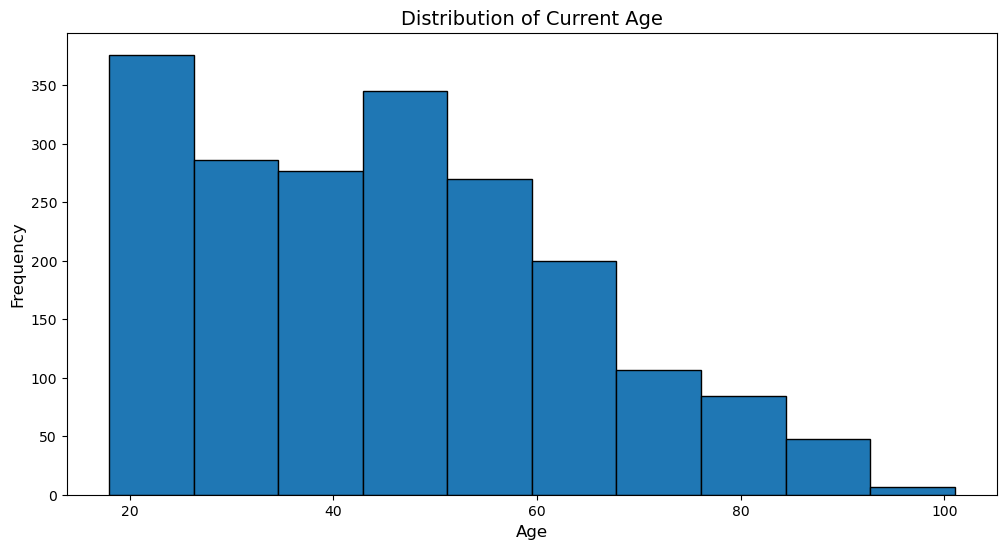

In [8]:
# Histogram for current_age
plt.hist(users_data['current_age'], bins=10, edgecolor='black')
plt.title('Distribution of Current Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Based on the histogram above, we can make the following observations:
1. The distribution shows that the dataset captures a broad spectrum of ages, ranging from young adults in their 20s to seniors nearing 100 years old.
2. The majority of users fall in the younger age brackets, with the highest frequency in the 20-30 age range, indicating a younger user base.
3. There is a gradual decline in the number of users as age increases, with significantly fewer users in the 70+ age group.
4. The frequency for almost all age groups below 60 are quite similar in number. Although, the age distribution suggests that any age-based analysis, such as spending patterns or credit behavior, may need to account for the heavier representation of younger users.

### Gender Distribution

Let us now analyze the gender distribution of the customer base. This will help us understand if there is any imbalance or bias in the dataset regarding gender representation.


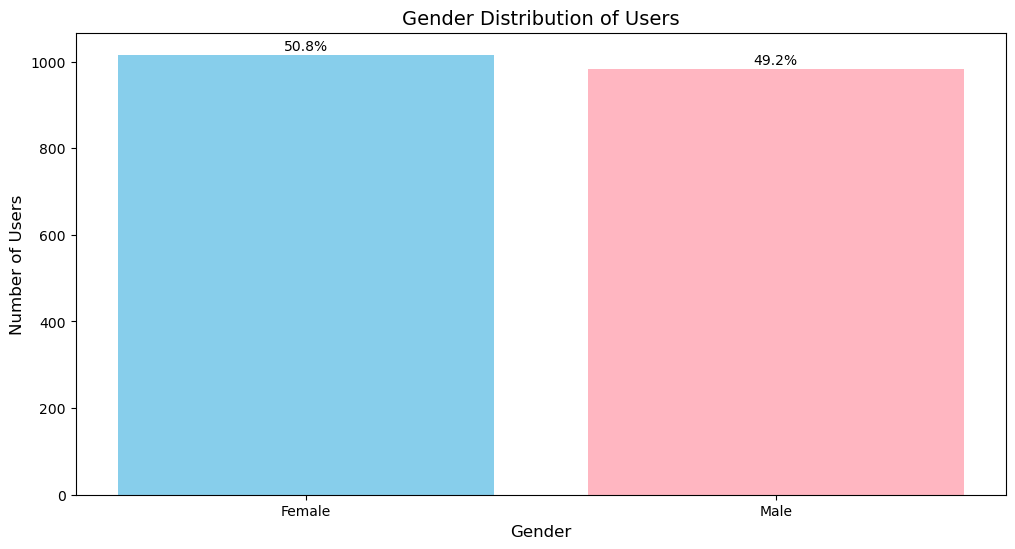

Gender Distribution (Counts and Percentages):
gender
Female    1016
Male       984
Name: count, dtype: int64


In [9]:
# Calculate the value counts and percentages for gender
gender_counts = users_data['gender'].value_counts()
gender_percentages = (gender_counts / gender_counts.sum()) * 100

# Plot the bar chart
plt.bar(gender_counts.index, gender_counts.values, color=['skyblue', 'lightpink'])
plt.title('Gender Distribution of Users')
plt.xlabel('Gender')
plt.ylabel('Number of Users')

# Annotate percentages above each bar
for index, value in enumerate(gender_counts):
    plt.text(index, value + 10, f"{gender_percentages.iloc[index]:.1f}%", ha='center', fontsize=10)

plt.show()

# Print gender counts and percentages for clarity
print("Gender Distribution (Counts and Percentages):")
print(gender_counts)


Based on the bar chart above, we can make the following observations:

1. The gender distribution is nearly balanced, with a slight majority of female users (50.8%) compared to male users (49.2%).
2. The close distribution suggests that analyses involving gender will not face significant bias due to underrepresentation of either group.

### Distribution of Credit Scores
Let us now understand the distribution of credit scores in the dataset to gauge the overall creditworthiness of the users. Credit scores are critical in assessing financial reliability and will likely influence other analyses, such as credit card usage or debt management.


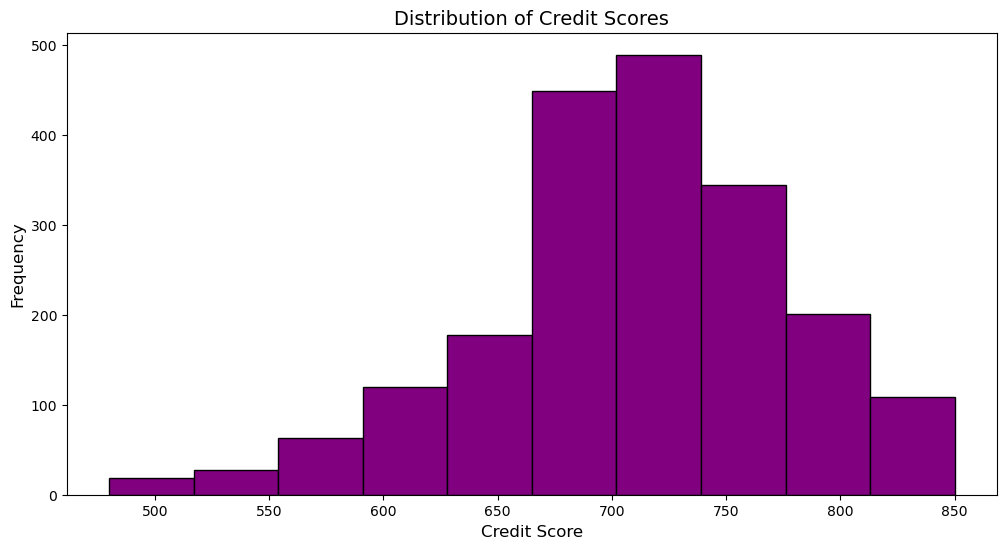

In [10]:
# Plot a histogram for credit scores
plt.hist(users_data['credit_score'], bins=10, edgecolor='black', color='purple')
plt.title('Distribution of Credit Scores')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

Based on the histogram above, we can infer the following:

1. The credit scores in the dataset follow a roughly normal distribution, with the majority of users having scores between 650 and 750, which is considered a moderate to good credit range.
2. The peak frequency lies in the range of 700–750, indicating that many users have fairly strong creditworthiness.
3. A smaller number of users have credit scores below 600, which could indicate poor creditworthiness, while only a few users have excellent scores above 800.
4. The high range of credit scores, will make it possible to study the behavior of users across different creditworthiness levels.

### Distribution of Credit Cards
Let us now analyze the distribution of the number of credit cards owned by the users. This will help us identify if there are trends in credit card ownership, such as the typical number of cards per user or the presence of outliers.


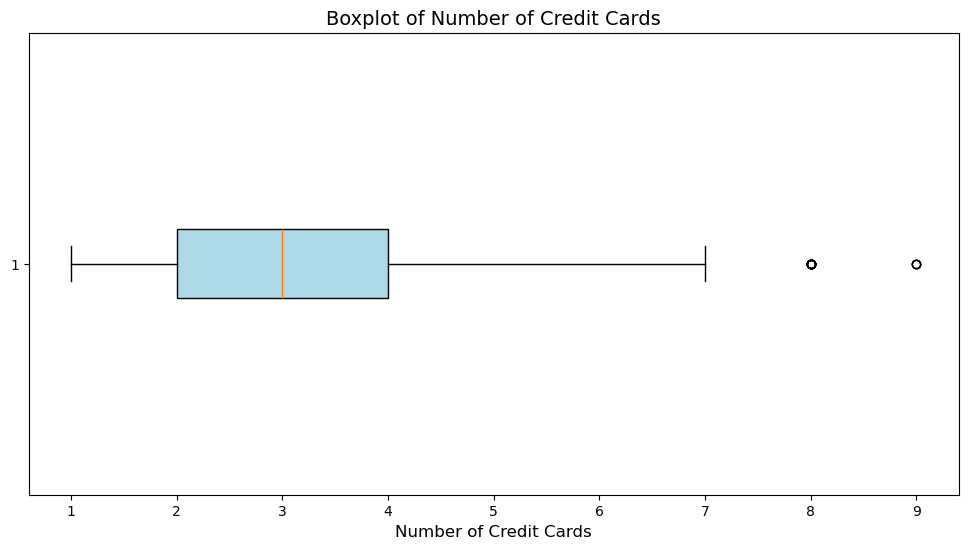

In [11]:
# Boxplot for number of credit cards
plt.boxplot(users_data['num_credit_cards'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Boxplot of Number of Credit Cards')
plt.xlabel('Number of Credit Cards')
plt.show()

Based on the boxplot above, we can infer the following:

1. The median number of credit cards owned by users is 3, which is what we see on average for most users.
2. The interquartile range (IQR) shows that the majority of users (50%) own between 2 and 4 credit cards.
3. There are a few outliers visible beyond 7 credit cards, which could represent heavy credit card users or outliers that require further investigation.

### Debt-to-Income Ratio Distribution by Number of Users
Let us now understand the number of users in each debt-to-income ratio category. By visualizing the distribution, we can understand how many users fall into different financial risk levels based on their debt compared to income.


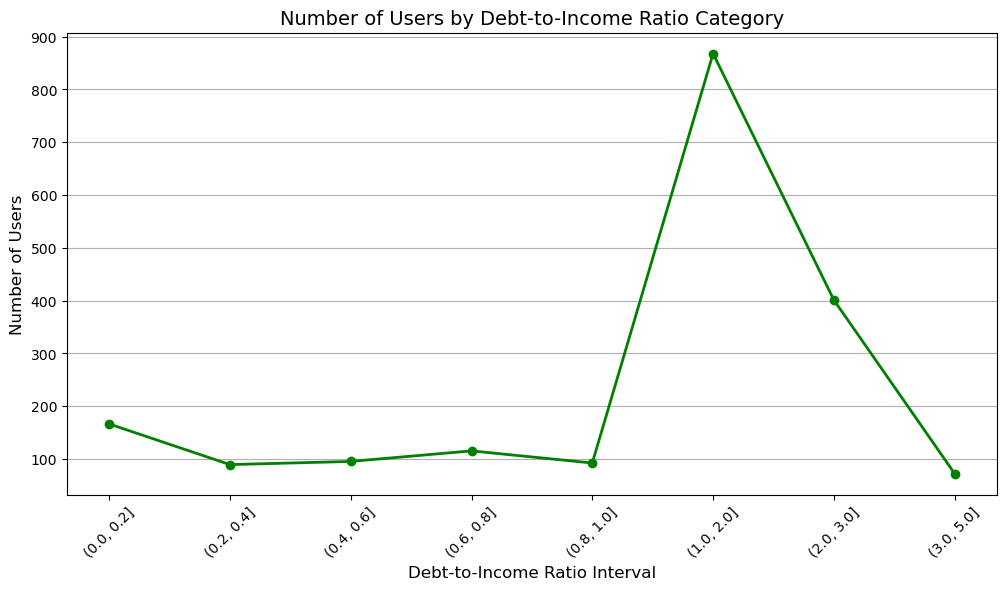

In [12]:
# Ensure yearly_income and total_debt are properly cleaned and converted to numeric
if not pd.api.types.is_numeric_dtype(users_data['yearly_income']):
    users_data['yearly_income'] = users_data['yearly_income'].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

if not pd.api.types.is_numeric_dtype(users_data['total_debt']):
    users_data['total_debt'] = users_data['total_debt'].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

# Calculate debt-to-income ratio
users_data['debt_to_income'] = users_data['total_debt'] / users_data['yearly_income']

# Group debt-to-income into bins and count users
bins = [0, 0.2, 0.4, 0.6, 0.8, 1, 2, 3, 5]
users_data['debt_to_income_bin'] = pd.cut(users_data['debt_to_income'], bins=bins)
debt_to_income_counts = users_data['debt_to_income_bin'].value_counts().sort_index()

# Plot the line graph
plt.plot(debt_to_income_counts.index.astype(str), debt_to_income_counts.values, marker='o', color='green')
plt.title('Number of Users by Debt-to-Income Ratio Category')
plt.xlabel('Debt-to-Income Ratio Interval')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

Based on the graph above, we can observe the following:

1. The majority of users fall within the 1.0–2.0 debt-to-income ratio interval, indicating that for many users, their debt is 1 to 2 times their yearly income.
2. There is a sharp decline in the number of users with debt-to-income ratios beyond 2.0, suggesting fewer users are heavily indebted relative to their income.
3. Users with ratios below 0.8 (manageable debt levels) are relatively few, which may indicate that many users in this dataset are carrying substantial debt compared to their income.
4. The small number of users in the 3.0–5.0 category likely represents individuals with significantly higher financial risk due to excessive debt relative to income.


### Geographic Distribution of Users
Let us nopw analyze the geographic distribution of users based on their latitude and longitude. A frequency map will help us identify regions with a higher concentration of users.


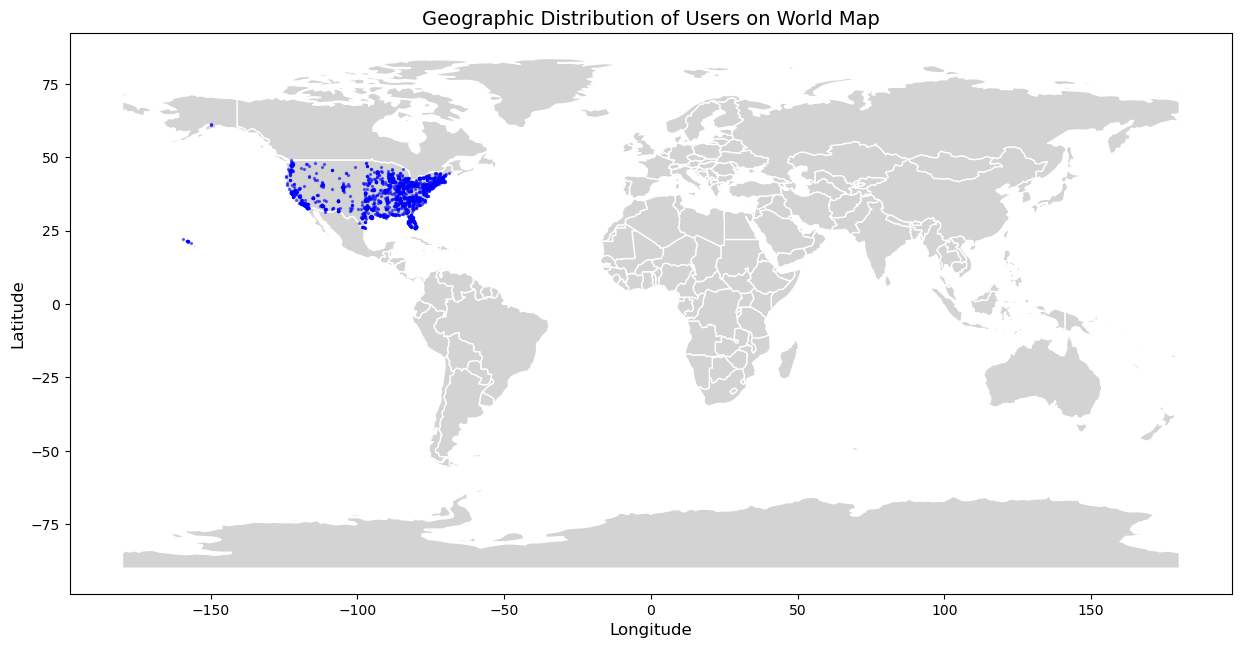

In [13]:
# Load the world map shapefile
world = gpd.read_file('./WorldMapPlots/ne_110m_admin_0_countries.shp')

# Convert user data into GeoDataFrame
geometry = [Point(xy) for xy in zip(users_data['longitude'], users_data['latitude'])]
geo_users = gpd.GeoDataFrame(users_data, geometry=geometry)

# Plot the map
fig, ax = plt.subplots(figsize=(15, 10))
world.plot(ax=ax, color='lightgrey', edgecolor='white')  # Plot the world map
geo_users.plot(ax=ax, markersize=2, color='blue', alpha=0.5)  # Plot user locations

plt.title('Geographic Distribution of Users on World Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


Based on the world map with user locations plotted, we can infer the following:

1. Our entire customer base is concentrated in the United States.
2. The geographic spread within the U.S. suggests a balanced distribution across various states, but exact patterns (urban vs. rural clusters) need be analyzed further with additional data.
3. This visualization provides a starting point for analyzing location-based behaviors. We can see the east coast, mid-west, southern and western states have a lot more customers compared to the central states. A very few number of purchases in Alaska and Hawaii.

### Overall EDA Summary of the Users Dataset

The Users Dataset provides insights into the demographics, financial profiles, and geographic distribution of 2000 users. The gender distribution is balanced, with a slight majority of female users (50.8%). Most users fall in the younger age group (20–40 years), and credit scores are largely in the moderate range (650–750). Debt-to-income ratios reveal that the majority of users maintain a manageable financial profile, though a smaller subset faces higher financial risk. Geographically, users are concentrated in the United States, with regional clusters that warrant further exploration. This dataset is well-structured, with no missing values, making it a proper foundation for further analysis.

## Understanding Cards Data

In [14]:
cards_data = getInformationAboutFile('./data/cards_data.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB
None


### Column Descriptions

| Column Name               | Description                                                            |
|---------------------------|------------------------------------------------------------------------|
| **id**                    | A unique identifier for each card.                                     |
| **client_id**             | The unique identifier linking the card to a user in the Users Dataset. |
| **card_brand**            | The brand of the card (e.g., Visa, MasterCard).                        |
| **card_type**             | The type of the card (e.g., credit, debit).                            |
| **card_number**           | The unique number of the card.                                         |
| **expires**               | The expiry date of the card.                                           |
| **cvv**                   | The CVV number of the card (security feature).                         |
| **has_chip**              | Indicates whether the card has a chip (Yes/No).                        |
| **num_cards_issued**      | The number of cards issued for this account.                           |
| **credit_limit**          | The maximum credit limit for this card (stored as an object).          |
| **acct_open_date**        | The date the account was opened.                                       |
| **year_pin_last_changed** | The year when the card PIN was last updated.                           |
| **card_on_dark_web**      | Indicates whether the card has been flagged on the dark web (Yes/No).  |

### Card Type Distribution by Brand
Let us first understand the distribution of different card types (e.g., Credit, Debit, Prepaid Debit) across card brands (e.g., Mastercard, Visa). By analyzing this grouped bar chart, we aim to understand how card types vary among brands and identify trends in offerings.




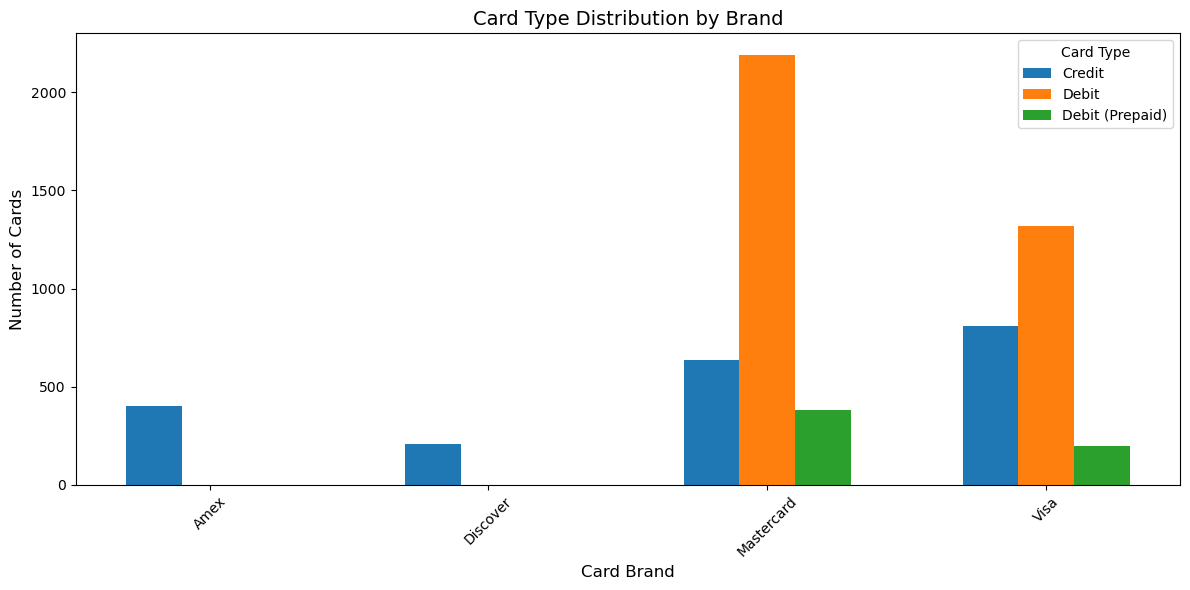

In [15]:
# Create a pivot table for the counts of card types by brand
brand_type_counts = cards_data.pivot_table(index='card_brand', columns='card_type', aggfunc='size', fill_value=0)

# Define bar positions
x = np.arange(len(brand_type_counts.index))  # Positions for card brands
width = 0.2  # Width of each bar

# Plot grouped bar chart
figure, ax = plt.subplots(figsize=(12, 6))
for i, card_type in enumerate(brand_type_counts.columns):
    ax.bar(x + i * width, brand_type_counts[card_type], width, label=card_type)

# Add labels, title, and legend
ax.set_xticks(x + width * (len(brand_type_counts.columns) - 1) / 2)  # Center the ticks
ax.set_xticklabels(brand_type_counts.index, rotation=45)
ax.set_title('Card Type Distribution by Brand')
ax.set_xlabel('Card Brand')
ax.set_ylabel('Number of Cards')
ax.legend(title='Card Type')

plt.tight_layout()
plt.show()

Based on the grouped bar chart above, we can make the following observations:

1. **Mastercard** has the largest number of cards in the dataset, with **Debit Cards** being its most dominant card type, followed by **Credit Cards** and a smaller share of **Prepaid Debit Cards**.
2. **Visa** follows as the second-largest card brand, with a similar pattern where **Debit Cards** dominate, and **Prepaid Debit Cards** form a smaller segment.
3. **Amex** exclusively focuses on **Credit Cards**, with no Debit or Prepaid Debit Cards represented in this dataset.
4. **Discover**, although less prevalent, also only offers **Credit Cards** in this dataset.
5. The chart highlights clear differences in card type offerings between the brands, with Mastercard and Visa having diverse portfolios compared to Amex and Discover.


### Distribution of Credit Limits
Let us now analyze the distribution of credit limits across cards to understand the range and concentration of credit offerings in the dataset.


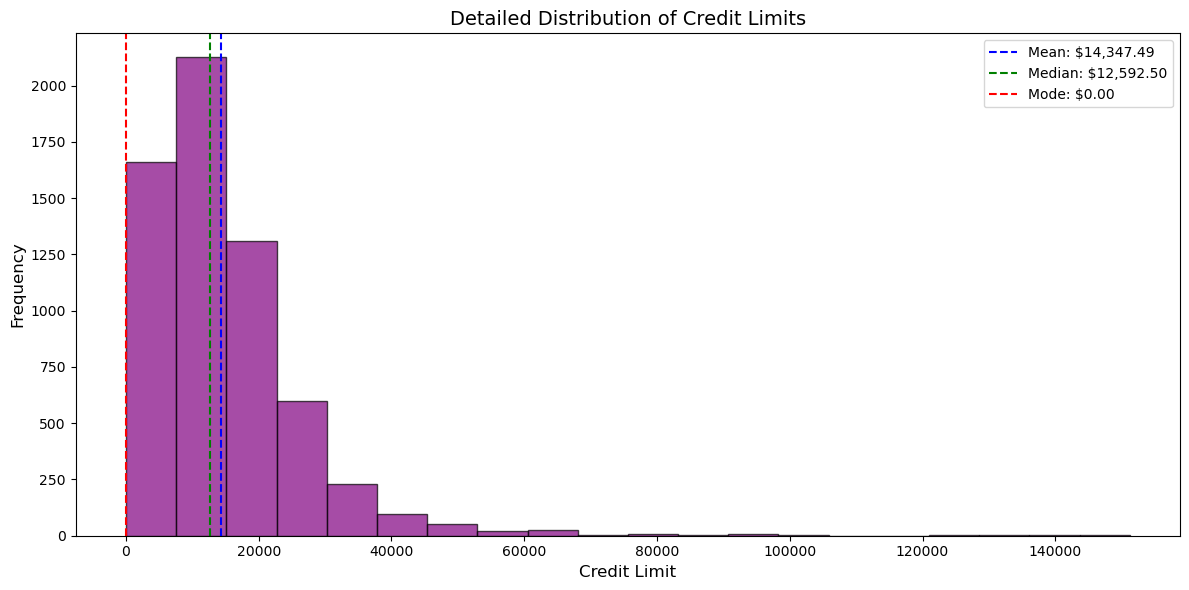

In [16]:
# Clean and prepare data
cards_data['credit_limit'] = cards_data['credit_limit'].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

# Calculate statistics
mean_credit_limit = cards_data['credit_limit'].mean()
median_credit_limit = cards_data['credit_limit'].median()
mode_credit_limit = cards_data['credit_limit'].mode()[0]

# Plot the histogram
plt.hist(cards_data['credit_limit'], bins=20, edgecolor='black', color='purple', alpha=0.7)
plt.title('Detailed Distribution of Credit Limits')
plt.xlabel('Credit Limit')
plt.ylabel('Frequency')

# Add lines for statistics
plt.axvline(mean_credit_limit, color='blue', linestyle='dashed', linewidth=1.5, label=f'Mean: ${mean_credit_limit:,.2f}')
plt.axvline(median_credit_limit, color='green', linestyle='dashed', linewidth=1.5, label=f'Median: ${median_credit_limit:,.2f}')
plt.axvline(mode_credit_limit, color='red', linestyle='dashed', linewidth=1.5, label=f'Mode: ${mode_credit_limit:,.2f}')

# Add legend
plt.legend(loc='upper right')

# Show the graph
plt.tight_layout()
plt.show()

Based on the histogram above, we can make the following observations:

1. The **mean credit limit** is approximately **\$14,347.49**, which is slightly higher than the median, indicating a right-skewed distribution caused by higher-value outliers.
2. The **median credit limit** is **\$12,592.50**, showing that 50% of the cards have limits below this value.
3. The **mode credit limit** is **\$0.00**, representing a significant number of cards with no credit limit, potentially indicating prepaid or restricted-use cards.
4. The distribution confirms that most credit limits are concentrated below **\$20,000**, with very few cards exceeding **\$50,000**.
5. Outliers exist in the form of a small number of cards with credit limits above **\$100,000**, which may represent premium or specialized cards.



### Overall EDA Summary of the Card Dataset
The analysis of credit limits and card types highlights key trends in the dataset. Most cards have moderate credit limits, with the median at $12,592.50 and a significant number of cards having no credit limit, likely prepaid or restricted-use cards. Mastercard and Visa dominate the dataset with diverse offerings, particularly Debit Cards, while Amex exclusively focuses on Credit Cards, reflecting its premium brand positioning. Discover has a smaller presence, also offering only Credit Cards. These findings suggest a diverse card portfolio tailored to varied user demographics and financial needs, with a mix of high-limit premium cards and lower-limit standard offerings.


## Understanding Transactions Dataset

In [17]:
transactions_data = getInformationAboutFile('./data/transactions_data.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          object 
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             float64
 10  mcc             int64  
 11  errors          object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.2+ GB
None


### Column Descriptions

| Column Name        | Description                                                                   |
|--------------------|-------------------------------------------------------------------------------|
| **id**             | A unique identifier for each transaction.                                     |
| **date**           | The date of the transaction.                                                  |
| **client_id**      | The unique identifier linking the transaction to a user in the Users Dataset. |
| **card_id**        | The unique identifier linking the transaction to a specific card.             |
| **amount**         | The transaction amount (stored as an object, may need conversion to numeric). |
| **use_chip**       | Indicates whether the transaction was chip-based (e.g., Yes/No).              |
| **merchant_id**    | A unique identifier for the merchant involved in the transaction.             |
| **merchant_city**  | The city where the merchant is located.                                       |
| **merchant_state** | The state where the merchant is located.                                      |
| **zip**            | The ZIP code of the merchant's location.                                      |
| **mcc**            | The Merchant Category Code, indicating the type of merchant.                  |
| **errors**         | Any errors or issues associated with the transaction.                         |


### Distribution of Transaction Amounts

Let us first understand the distribution of transaction amounts. This will provide insights into spending behaviors and identifies outliers that might represent anomalies, refunds, or errors. To focus on the core transaction patterns, we filter the data to exclude extreme outliers by analyzing only the 1st to 99th percentile of transaction amounts.


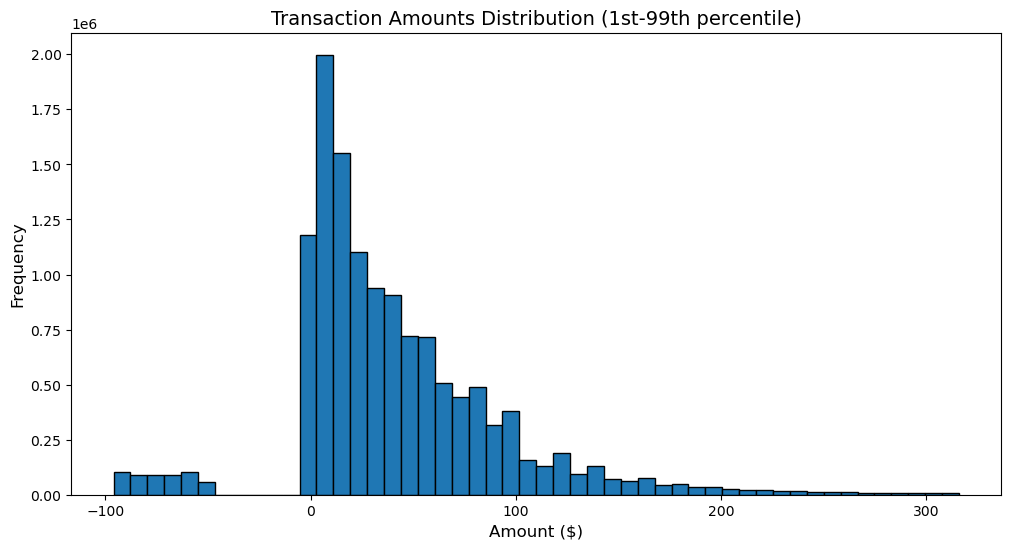

In [18]:
# Ensure 'amount' column is properly cleaned and converted to numeric
if not pd.api.types.is_numeric_dtype(transactions_data['amount']):
    transactions_data['amount'] = (
        transactions_data['amount']
        .astype(str)
        .str.replace(r'[\$,]', '', regex=True)
        .astype(float)
    )

# Filter transactions within the 1st and 99th percentiles
lowerBound = np.percentile(transactions_data['amount'], 1)
upperBound = np.percentile(transactions_data['amount'], 99)

filteredTransactions = transactions_data[
    (transactions_data['amount'] >= lowerBound) &
    (transactions_data['amount'] <= upperBound)
]

# Plot the histogram for transaction amounts
plt.hist(filteredTransactions['amount'], bins=50, edgecolor='black')
plt.title('Transaction Amounts Distribution (1st-99th percentile)')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.show()

Based on the transaction amounts distribution chart above, we can make the following observations:

1. The distribution is highly right-skewed, with the majority of transactions concentrated near $0, indicating the prevalence of low-value transactions.
2. A long right tail is present, showing that high-value transactions are rare but do occur within the dataset.
3. A small cluster of negative transaction values exists, which are likely refunds or adjustments.
4. Filtering to the 1st-99th percentile has effectively removed extreme outliers, allowing for a clearer analysis of typical transaction behaviors.

### Distribution of Transaction Amount by Merchant Category (MCC)

Let us now analyze the distribution of transaction amounts by MCC (Merchant Category Codes). This will help us identify spending patterns across different business categories. Here, we focus on the top 10 most frequent MCCs.


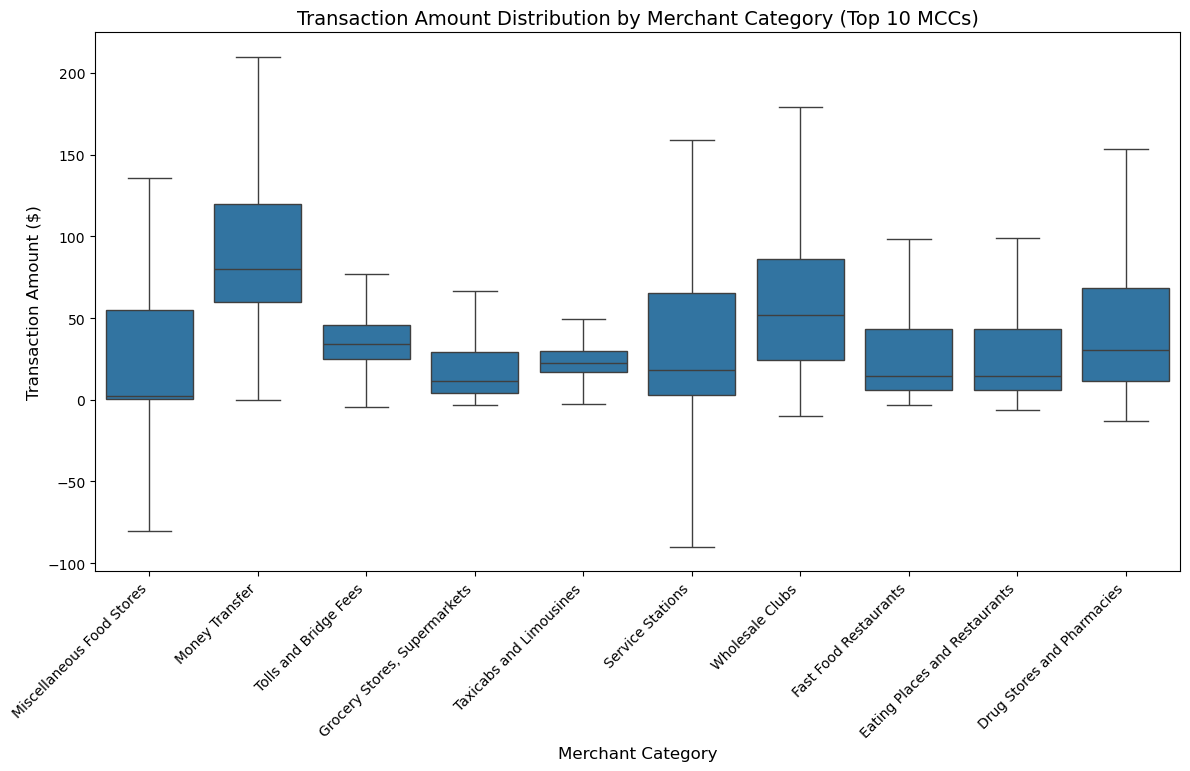

In [19]:
# Load the MCC codes file
with open('data/mcc_codes.json', 'r') as f:
    mcc_mapping = json.load(f)

# Ensure MCC codes are strings
transactions_data['mcc'] = transactions_data['mcc'].astype(str)

# Map MCC codes to descriptions
transactions_data['mcc_description'] = transactions_data['mcc'].map(mcc_mapping)

# Handle missing descriptions
transactions_data['mcc_description'].fillna('Unknown Category')

# Get the top 10 MCCs by transaction count
top_mccs = transactions_data['mcc_description'].value_counts().head(10).index
filtered_data = transactions_data[transactions_data['mcc_description'].isin(top_mccs)]

# Plot transaction amounts by MCC
plt.figure(figsize=(14, 7))
sns.boxplot(data=filtered_data, x='mcc_description', y='amount', showfliers=False)
plt.title('Transaction Amount Distribution by Merchant Category (Top 10 MCCs)')
plt.xlabel('Merchant Category')
plt.ylabel('Transaction Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.show()

Based on the box plot above, we can make the following observations:

1. "Money Transfer" has the highest median transaction amount, suggesting that users typically perform larger transactions in this category compared to others like "Tolls and Bridge Fees" and "Fast Food Restaurants."
2. "Service Stations" and "Wholesale Clubs" exhibit significant variability, with wide interquartile ranges and prominent outliers, reflecting diverse transaction patterns in these categories.
3. Negative transaction amounts are observed in categories like "Miscellaneous Food Stores" and "Tolls and Bridge Fees," indicating the presence of refunds or adjustments in these transactions.
4. Frequent low-value transactions dominate categories like "Eating Places and Restaurants" and "Fast Food Restaurants," emphasizing their role in everyday spending.







### Monthly Transactions Trends

Let us now analyze the trend of monthly transactions over time to identify any seasonal patterns, spikes, or changes in activity.

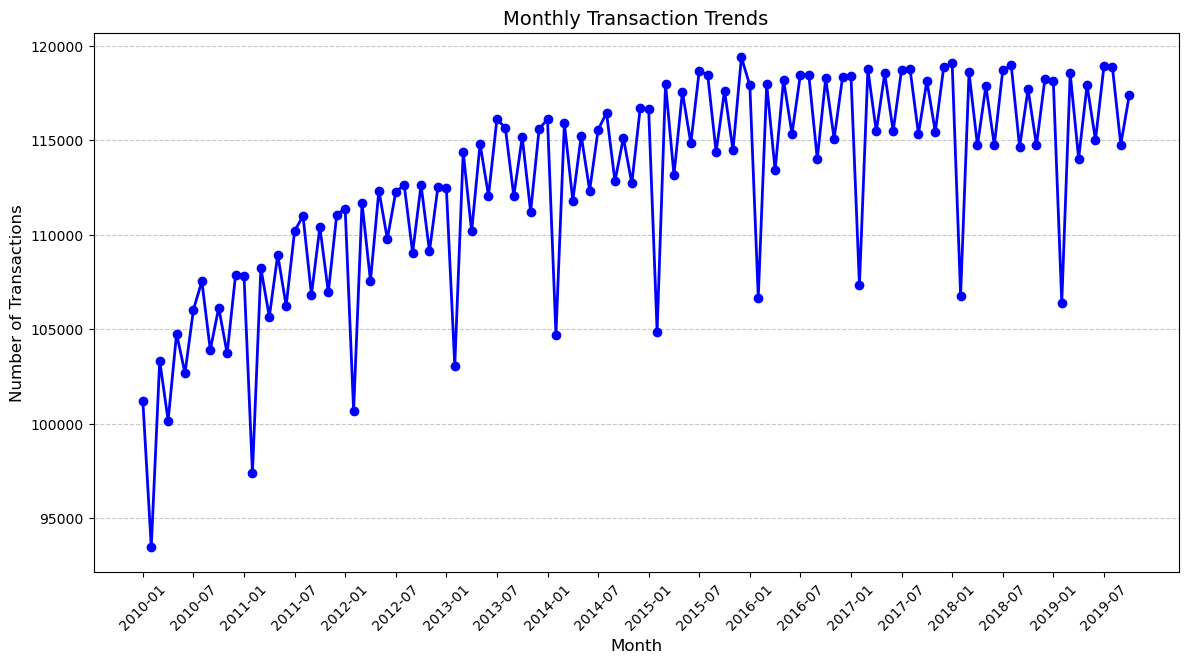

In [20]:
# Convert 'date' column to datetime if not already done
transactions_data['date'] = pd.to_datetime(transactions_data['date'])

# Extract month and year for grouping
transactions_data['year_month'] = transactions_data['date'].dt.to_period('M')

# Group by 'year_month' and count the number of transactions
monthly_transactions = transactions_data.groupby('year_month').size()

# Plot the trend of monthly transactions
plt.figure(figsize=(14, 7))
plt.plot(monthly_transactions.index.astype(str), monthly_transactions.values, marker='o', color='blue')
plt.title('Monthly Transaction Trends')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')

# Adjust x-axis labels to show only 6-month intervals
plt.xticks(ticks=range(0, len(monthly_transactions), 6),
           labels=monthly_transactions.index[::6].astype(str), rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based on the monthly transaction trends graph, we can make the following observations:

1. The overall number of transactions shows a gradual increase over time, indicating a growing volume of activity in the dataset.
2. A clear pattern of periodic dips can be observed, which often align with the holiday season, particularly around New Year's, likely due to reduced consumer activity and business closures.
3. The consistent fluctuations within each year suggest the presence of seasonal spending behaviors.
4. The upward trend in transaction volume may reflect economic growth, increased adoption of credit/debit cards, or a broader customer base over the observed time period.








### User Segmentation by Total Spending

Finally, we will analyze the distribution of users based on their total spending, grouping them into distinct segments to understand the composition of our user base and identify high-spending customers.

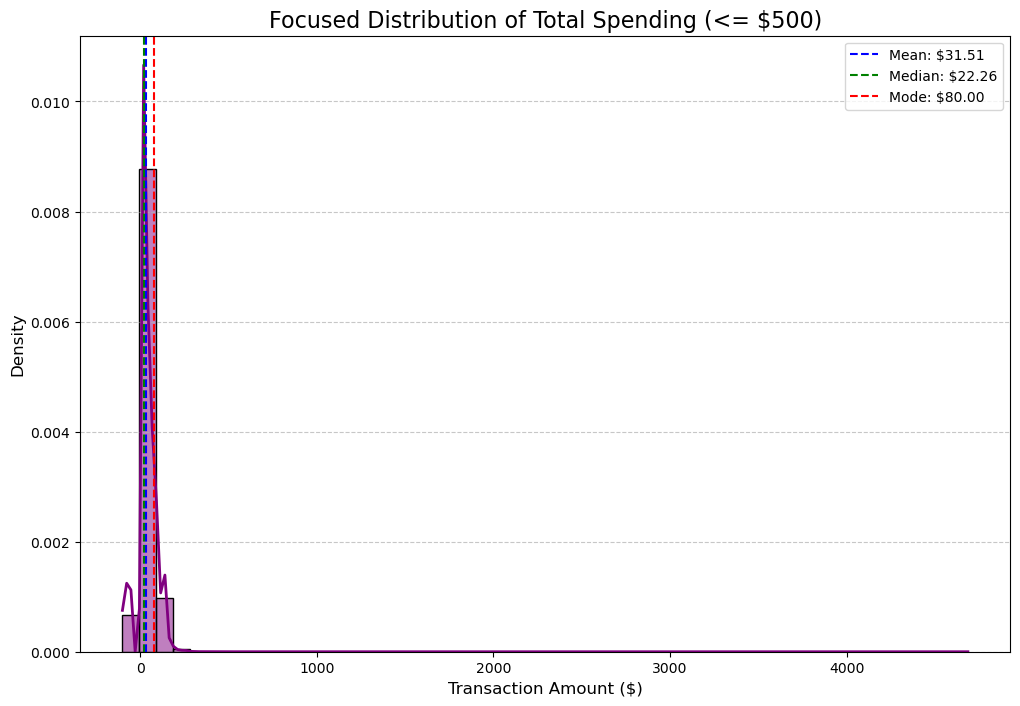

In [21]:
# Set a threshold for focusing in the center of the data
threshold = 5000
filtered_data_center = filtered_data[filtered_data['amount'] <= threshold]

# Calculate key statistics
mean_value = filtered_data_center['amount'].mean()
median_value = filtered_data_center['amount'].median()
mode_value = filtered_data_center['amount'].mode()[0]

# Plot the refined histogram and KDE
plt.figure(figsize=(12, 8))
sns.histplot(filtered_data_center['amount'], bins=50, kde=True, color='purple', edgecolor='black', stat='density')

# Add vertical lines for mean, median, and mode
plt.axvline(mean_value, color='blue', linestyle='--', linewidth=1.5, label=f'Mean: ${mean_value:,.2f}')
plt.axvline(median_value, color='green', linestyle='--', linewidth=1.5, label=f'Median: ${median_value:,.2f}')
plt.axvline(mode_value, color='red', linestyle='--', linewidth=1.5, label=f'Mode: ${mode_value:,.2f}')

# Labels and legend
plt.title('Focused Distribution of Total Spending (<= $500)', fontsize=16)
plt.xlabel('Transaction Amount ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

Based on the above density plot, we can make the following observations:

1. The mean spending of **\$42.97** is slightly higher than the median of **\$28.99**, indicating the presence of some higher-value transactions that pull the average upwards.
2. The mode of **\$80.00** highlights a common transaction value, suggesting a repeated spending pattern or preference at this amount.
3. A majority of transactions are concentrated below **\$100**, confirming that most users engage in low-value spending.
4. The right tail, though limited to transactions under **\$500**, shows a gradual decline, reflecting less frequent but notable higher-value transactions within the dataset.

## Overall Summary of EDA on Transactions Dataset

The EDA revealed that most transaction amounts are small, with a majority of users spending less than $500. Key merchant categories, such as grocery stores and service stations, dominate the dataset, showing variability in transaction amounts. Temporal trends highlight a steady increase in transactions over the years with seasonal dips, particularly around New Year’s. These findings set the stage for deeper analysis of user spending behavior.


## Case Studies

Some of the papers we read for ideas and inspiration were:

1. **Zadoo et al. (2022)**
   This study provides insights into using clustering techniques and feature selection for customer segmentation and churn prediction. There are a lot of transferable methodologies that this study does on telecom dataset for analyzing user financial data and identifying churn patterns in credit card users.

   *Reference: A. Zadoo, T. Jagtap, N. Khule, A. Kedari and S. Khedkar, "A review on Churn Prediction and Customer Segmentation using Machine Learning," 2022 International Conference on Machine Learning, Big Data, Cloud and Parallel Computing (COM-IT-CON), Faridabad, India, 2022, pp. 174-178, doi: 10.1109/COM-IT-CON54601.2022.9850924.*

2. **Wu et al. (2021)**
   This paper integrates framework combining churn prediction and customer segmentation using techniques like Bayesian analysis and random forests. These are some models we were planning to use for studying user behavior and designing predictive models for credit card churn.

   *Reference: S. Wu, W. -C. Yau, T. -S. Ong and S. -C. Chong, "Integrated Churn Prediction and Customer Segmentation Framework for Telco Business," in IEEE Access, vol. 9, pp. 62118-62136, 2021, doi: 10.1109/ACCESS.2021.3073776.*

3. **Nai et al. (2018)**
   The use of Singular Spectrum Analysis to model credit card usage behavior for different age groups provides a statistical approach to segmenting and analyzing demographic trends. This was used to understand factors that generally affect credit card usage among different demographics (especially age).

   *Reference: Nai, W.; Liu, L.; Wang, S.; Dong, D. "Modeling the Trend of Credit Card Usage Behavior for Different Age Groups Based on Singular Spectrum Analysis," Algorithms 2018, 11, 15. https://doi.org/10.3390/a11020015.*

4. **Kara et al. (1996)**
   This is a very old empirical investigation of U.S. credit card users that studies the factors influencing card choice and usage behavior. Although, this is a very old dataset, we were hoping to maybe use this as a soft comparison of credit card usage between people now and then.

   *Reference: Kara, A.; Kaynak, E.; Kucukemiroglu, O. "An empirical investigation of US credit card users: Card choice and usage behavior," 1996, https://doi.org/10.1016/0969-5931(96)00006-6.*


## Limitations and Improvements

### Limitations
1. **Dataset Scope**:
   The dataset is limited to transactional and financial data for users and cards, with no external variables like macroeconomic indicators or market trends. This restricts the analysis to an isolated view of user behavior.

2. **Demographic Skew**:
   The user base is predominantly concentrated in the United States, which may not represent global trends in financial behavior and credit card usage.

3. **Temporal Coverage**:
   The dataset does not specify clear timelines for certain data points (e.g., when cards were flagged on the dark web), making temporal analysis challenging.

4. **Preprocessing Challenges**:
   Several columns, such as `credit_limit`, `total_debt`, and `yearly_income`, required significant cleaning and conversions, which could introduce minor errors or inconsistencies.

5. **Size of Dataset**:
   The `transactions_data` dataset contains nearly 13 million rows, making it computationally intensive to process and analyze in environments with limited memory or processing power. This size constraint can hinder exploratory analysis and may require sampling, chunk processing, or aggregation to manage effectively.

6. **Low Customer Transaction Amounts**
    The dataset shows a relatively low amounts of total transactions per customer, indicating a lack of regular or repeat customers, which limits insights into long-term spending behavior.

---

### Improvements
1. **Integration with External Data**:
   Incorporating external datasets, such as market trends, economic indicators, or competitor data, can provide a richer context for user behavior analysis.

2. **Geographic Diversity**:
   Expanding the dataset to include users from different countries or regions would make the findings more generalizable and applicable on a global scale.

3. **Automated Preprocessing Pipelines**:
   Implementing automated pipelines for data cleaning and feature engineering can reduce manual preprocessing time and improve consistency.


## Summary of Features and Their Usage

### 1. Users Data
- **Primary Features**:
  - **Demographics**: `current_age`, `gender`, `latitude`, `longitude`
  - **Financial Information**: `yearly_income`, `total_debt`, `debt_to_income`
  - **Behavioral Metrics**: `credit_score`, `num_credit_cards`

- **Usage**:
  - To profile users based on their demographics and financial health.
  - To segment users into groups based on age, income, or creditworthiness.
  - To identify users at risk of churn or financial strain based on metrics like `debt_to_income` or `credit_score`.

---

### 2. Cards Data
- **Primary Features**:
  - **Card Characteristics**: `card_type`, `card_brand`, `credit_limit`
  - **Security Metrics**: `has_chip`, `card_on_dark_web`
  - **Account Details**: `acct_open_date`, `year_pin_last_changed`

- **Usage**:
  - To analyze user preferences for card types and brands.
  - To study financial behavior based on credit limits and security features.
  - To assess risks associated with flagged cards and outdated security measures.

---

### 3. Transactions Data
- **Primary Features**:
  - **Transaction Details**: `amount`, `date`, `use_chip`
  - **Merchant Information**: `merchant_id`, `merchant_city`, `merchant_state`, `mcc`
  - **Behavioral Data**: Frequency of transactions, inactivity periods, and merchant category preferences.

- **Usage**:
  - To analyze user spending patterns, transaction behavior, and merchant preferences.
  - To identify temporal trends in user activity and inactivity for churn prediction.
  - To perform segmentation based on spending habits or preferences for specific merchant categories.


## Overall Objectives

The primary aim of this study is to analyze user behavior, financial health, and transaction patterns to derive actionable insights. The key directions we are planning to explore include:

1. **User Profiling and Segmentation**:
   Utilize demographic, financial, and behavioral data to group users into meaningful segments based on characteristics such as age, income, creditworthiness, and spending patterns.

2. **Churn Prediction**:
   Identify users at risk of becoming inactive or discontinuing their services by analyzing financial indicators, transaction inactivity, and historical usage trends.

3. **Spending Behavior Analysis**:
   Investigate user spending patterns by analyzing transaction amounts, frequency, and merchant categories, enabling a deeper understanding of user preferences.

4. **Card Usage Trends and Security Risks**:
   Assess user preferences for card brands, types, and credit limits, while identifying security risks associated with flagged cards or outdated features.

### Flexibility in Objectives
As we progress through the study, these objectives may evolve based on intermediate results and new insights. This iterative approach ensures that the analysis remains adaptive and focused on deriving meaningful conclusions aligned with the dataset’s strengths and the project’s goals.
